### Approximating the Sine Function with Polynomial Regression: A Controlled Study of Underfitting and Overfitting

####  Introduction and Motivation

In the companion project on Bitcoin price prediction, the polynomial degree selected by `GridSearchCV`
was consistently low (degree 1), which raised a natural question: *can higher-degree polynomial models
ever actually be the right choice?* The answer is yes — but only under specific conditions that the
Bitcoin dataset does not satisfy. This project is designed as a **controlled experiment** to make that
distinction explicit.

####  Why the Sine Function Is a Good Teaching Example

- It is **smooth and genuinely nonlinear** — a straight line (degree 1) cannot represent it at all,
  guaranteeing visible underfitting at low degree, which was not obvious in the near-linear Bitcoin case.



## 1. Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings


warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_style("whitegrid")

## 2. Synthetic Data Generation

Unlike the Bitcoin project, where the data was collected from an external time series and shuffling was
forbidden, here the samples are **independent and identically distributed (i.i.d.)** — each $x$ is drawn
independently from a uniform distribution, so shuffling and a simple random train/test split are
perfectly valid.


In [4]:
rng = np.random.default_rng(42)

n_samples = 120
noise_std = 0.2

x = rng.uniform(0, 2 * np.pi, size=n_samples)
noise = rng.normal(loc=0.0, scale=noise_std, size=n_samples)
y = np.sin(x) + noise

# Dense grid for plotting the true, noise-free sine curve
x_true = np.linspace(0, 2 * np.pi, 400)
y_true = np.sin(x_true)

X = x.reshape(-1, 1)
print(X.shape, y.shape)

(120, 1) (120,)


### 2.1. Visualizing the Raw Data Against the True Function

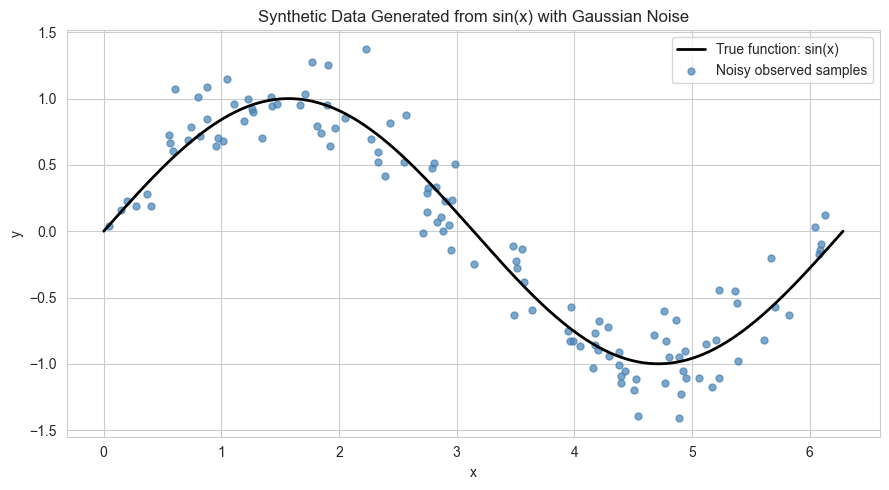

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(x_true, y_true, label="True function: sin(x)", color="black", linewidth=2)
plt.scatter(x, y, label="Noisy observed samples", color="steelblue", alpha=0.7, s=25)
plt.title("Synthetic Data Generated from sin(x) with Gaussian Noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Train / Test Split

Because the data is i.i.d. (no temporal ordering to preserve), a standard random split with shuffling is
appropriate here — unlike the Bitcoin project, where `shuffle=False` was mandatory.

In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
print("train size:", len(x_train))
print("test size :", len(x_test))

train size: 96
test size : 24


## 4. Feature Generation

With only a single raw input ($x$), no manual feature engineering (of the kind used for Bitcoin, e.g.
`Close-Open`) is needed or meaningful here. Instead, the `PolynomialFeatures` step of the pipeline is
itself the feature-generation mechanism: given degree $d$, it automatically constructs the feature set
$\{x, x^2, x^3, \dots, x^d\}$. Choosing $d$ via `GridSearchCV` is therefore equivalent to letting the
model search over an entire family of feature sets of increasing complexity — from the simplest
(degree 1, a straight line) to highly flexible, high-order curves.

## 5. Modeling: `Pipeline` + `GridSearchCV` for Each Model Independently

As in the Bitcoin project, each model has its own `Pipeline`:

$$\text{StandardScaler} \;\rightarrow\; \text{PolynomialFeatures} \;\rightarrow\; \text{Regressor}$$

Scaling still matters here: at high degrees, $x^{15}$ over $[0, 2\pi]$ spans a very large numeric range,
which can destabilize the closed-form solvers used by `LinearRegression` and `Ridge`.

The search grid intentionally spans a **wide range of degrees (1 to 15)** — much wider than in the
Bitcoin project — specifically so that both underfitting (very low degree) and overfitting (very high
degree) are represented in the search space, letting cross-validation clearly reveal the sweet spot in
between.

### 5.1. Linear Regression

In [5]:
pipeline_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", LinearRegression()),
])

param_grid_linear = {
    "poly__degree": list(range(1, 16)),
}

gs_linear = GridSearchCV(pipeline_linear, param_grid_linear, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_linear.fit(x_train, y_train)

print("best params (Linear):", gs_linear.best_params_)
print("best CV RMSE (Linear):", -gs_linear.best_score_)

best params (Linear): {'poly__degree': 3}
best CV RMSE (Linear): 0.20519539805150805


### 5.2. Lasso (L1 Regularization)

In [6]:
pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", Lasso(max_iter=200000, tol=1e-2)),
])

param_grid_lasso = {
    "poly__degree": list(range(1, 16)),
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
}

gs_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_lasso.fit(x_train, y_train)

print("best params (Lasso):", gs_lasso.best_params_)
print("best CV RMSE (Lasso):", -gs_lasso.best_score_)

best params (Lasso): {'model__alpha': 0.001, 'poly__degree': 3}
best CV RMSE (Lasso): 0.2053159794288301


### 5.3. Ridge (L2 Regularization)

In [7]:
pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", Ridge()),
])

param_grid_ridge = {
    "poly__degree": list(range(1, 16)),
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
}

gs_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_ridge.fit(x_train, y_train)

print("best params (Ridge):", gs_ridge.best_params_)
print("best CV RMSE (Ridge):", -gs_ridge.best_score_)

best params (Ridge): {'model__alpha': 0.1, 'poly__degree': 3}
best CV RMSE (Ridge): 0.20512797162151458


### 5.4. Elastic Net (Combined L1 and L2 Regularization)

In [8]:
pipeline_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", ElasticNet(max_iter=200000, tol=1e-2)),
])

param_grid_elastic = {
    "poly__degree": list(range(1, 16)),
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

gs_elastic = GridSearchCV(pipeline_elastic, param_grid_elastic, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_elastic.fit(x_train, y_train)

print("best params (Elastic Net):", gs_elastic.best_params_)
print("best CV RMSE (Elastic Net):", -gs_elastic.best_score_)

best params (Elastic Net): {'model__alpha': 0.001, 'model__l1_ratio': 0.1, 'poly__degree': 3}
best CV RMSE (Elastic Net): 0.2051480438362237


## 6. Quantitative Model Comparison

As in the Bitcoin project, results are collected into a single comparison table (RMSE and R² on both
train and test sets, plus the best cross-validated RMSE and hyperparameters for each model).

In [9]:
fitted_searches = {
    "Linear": gs_linear,
    "Ridge": gs_ridge,
    "Lasso": gs_lasso,
    "ElasticNet": gs_elastic,
}

results = []
best_estimators = {}

for name, gs in fitted_searches.items():
    best_estimators[name] = gs.best_estimator_

    y_pred_train = gs.predict(x_train)
    y_pred_test = gs.predict(x_test)

    results.append({
        "model": name,
        "best_params": gs.best_params_,
        "cv_best_rmse": -gs.best_score_,
        "rmse_train": root_mean_squared_error(y_train, y_pred_train),
        "rmse_test": root_mean_squared_error(y_test, y_pred_test),
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test),
    })

results_df = pd.DataFrame(results).sort_values("rmse_test").reset_index(drop=True)
results_df

,model,best_params,cv_best_rmse,rmse_train,rmse_test,r2_train,r2_test
0,Lasso,"{'model__alpha': 0.001, 'poly__degree': 3}",0.205316,0.197875,0.217650,0.937340,0.904571
1,Ridge,"{'model__alpha': 0.1, 'poly__degree': 3}",0.205128,0.197830,0.218334,0.937368,0.903970
2,ElasticNet,"{'model__alpha': 0.001, 'model__l1_ratio': 0.1...",0.205148,0.197830,0.218336,0.937368,0.903969
3,Linear,{'poly__degree': 3},0.205195,0.197786,0.220124,0.937396,0.902389


### 6.1. Diagnostic: Cross-Validated RMSE vs Polynomial Degree

This is the same diagnostic used in the Bitcoin project, extracted from `cv_results_`: for each degree
tested, the best cross-validated RMSE achieved at that degree (across all other hyperparameters searched)
is plotted. Unlike the Bitcoin case, where RMSE increased steadily from degree 1 onward, here RMSE is
expected to **decrease** from degree 1 as the model gains the flexibility to trace the sine curve, reach
a minimum around a moderate degree, and then **increase again** at very high degrees as overfitting sets
in — the classic U-shaped bias-variance curve.

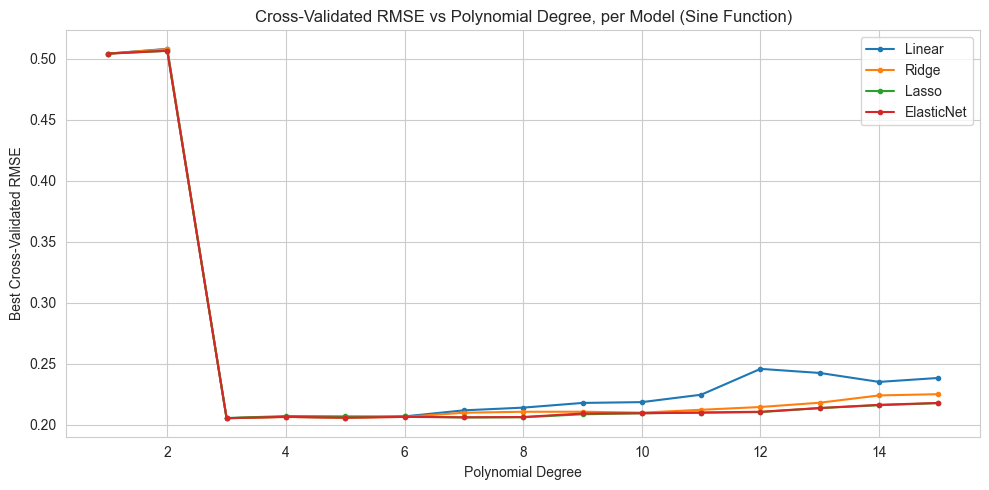

model,ElasticNet,Lasso,Linear,Ridge
degree,,,,
1,0.504262,0.504279,0.504263,0.504260
2,0.506641,0.506525,0.508158,0.507965
3,0.205148,0.205316,0.205195,0.205128
4,0.206266,0.206887,0.206334,0.206185
5,0.205606,0.206635,0.205529,0.205491
6,0.206237,0.206579,0.206635,0.206262
7,0.205909,0.205784,0.211631,0.209667
8,0.206142,0.205945,0.213837,0.210452
9,0.209031,0.208391,0.217695,0.210478


In [10]:
degree_diagnostics = []

for name, gs in fitted_searches.items():
    cv_df = pd.DataFrame(gs.cv_results_)
    cv_df["rmse"] = -cv_df["mean_test_score"]
    best_per_degree = cv_df.groupby("param_poly__degree")["rmse"].min()
    for degree, rmse in best_per_degree.items():
        degree_diagnostics.append({"model": name, "degree": degree, "best_cv_rmse": rmse})

degree_diag_df = pd.DataFrame(degree_diagnostics)

plt.figure(figsize=(10, 5))
for name in fitted_searches.keys():
    subset = degree_diag_df[degree_diag_df["model"] == name].sort_values("degree")
    plt.plot(subset["degree"], subset["best_cv_rmse"], marker="o", markersize=3, label=name)

plt.xlabel("Polynomial Degree")
plt.ylabel("Best Cross-Validated RMSE")
plt.title("Cross-Validated RMSE vs Polynomial Degree, per Model (Sine Function)")
plt.legend()
plt.tight_layout()
plt.show()

degree_diag_df.pivot(index="degree", columns="model", values="best_cv_rmse")

## 7. Explicit Visualization: Underfitting, Good Fit, and Overfitting

To make the bias-variance tradeoff directly visible, three **unregularized** `LinearRegression` models
are fit at three fixed degrees using the same training data:

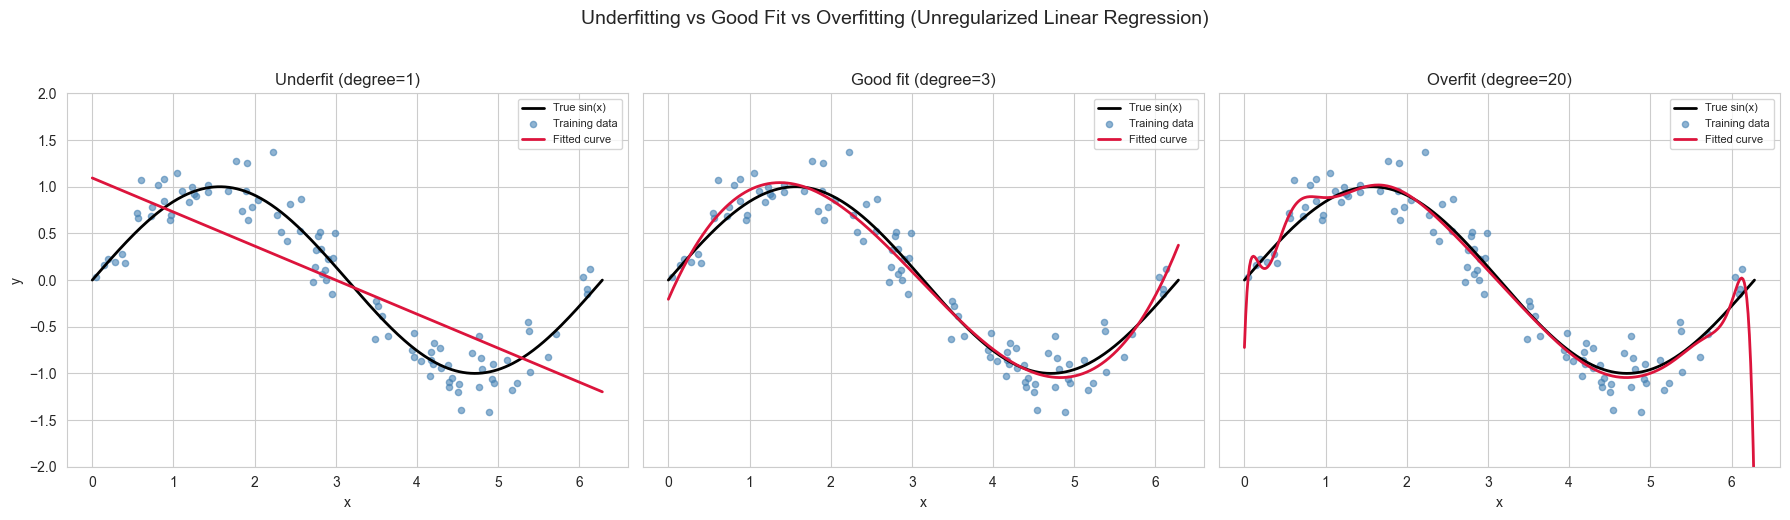

In [11]:
good_degree = gs_linear.best_params_["poly__degree"]
degrees_to_show = {"Underfit (degree=1)": 1, f"Good fit (degree={good_degree})": good_degree, "Overfit (degree=20)": 20}

x_grid = np.linspace(0, 2 * np.pi, 400).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, degree) in zip(axes, degrees_to_show.items()):
    demo_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree)),
        ("model", LinearRegression()),
    ])
    demo_pipeline.fit(x_train, y_train)
    y_grid_pred = demo_pipeline.predict(x_grid)

    ax.plot(x_true, y_true, color="black", linewidth=2, label="True sin(x)")
    ax.scatter(x_train, y_train, color="steelblue", alpha=0.6, s=20, label="Training data")
    ax.plot(x_grid, y_grid_pred, color="crimson", linewidth=2, label="Fitted curve")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8)

axes[0].set_ylabel("y")
fig.suptitle("Underfitting vs Good Fit vs Overfitting (Unregularized Linear Regression)", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

## 8. Good-Fit Comparison Across All Four Models

Here, the best (`GridSearchCV`-selected) fitted curve from **each of the four models** is plotted
together against the true sine curve, to compare how Linear, Ridge, Lasso, and Elastic Net approximate
the same underlying function once each has been allowed to pick its own optimal degree and regularization
strength.

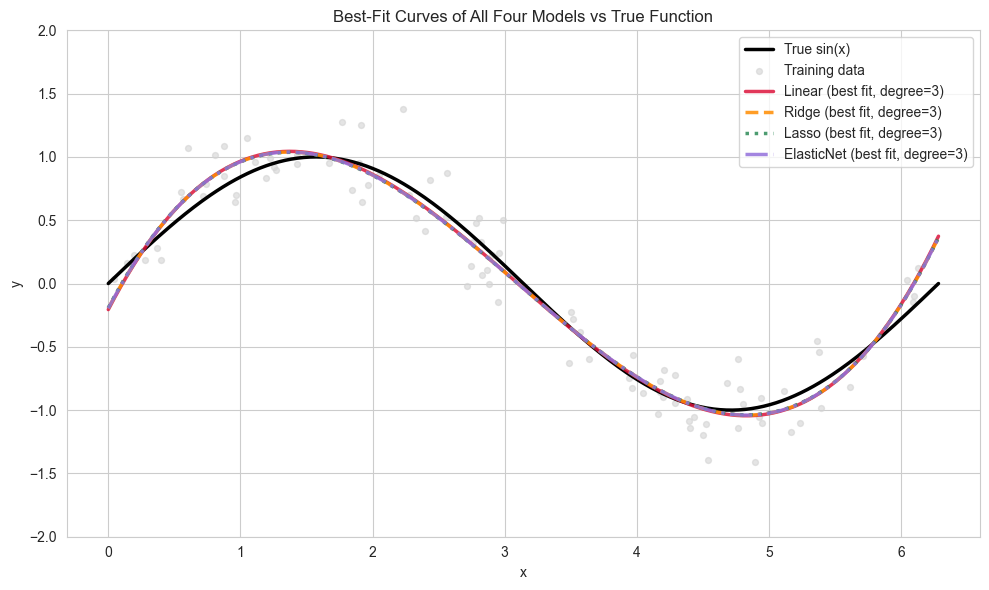

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(x_true, y_true, color="black", linewidth=2.5, label="True sin(x)")
plt.scatter(x_train, y_train, color="lightgray", alpha=0.6, s=18, label="Training data")

styles = {
    "Linear": {"color": "crimson", "linestyle": "solid"},
    "Ridge": {"color": "darkorange", "linestyle": "dashed"},
    "Lasso": {"color": "seagreen", "linestyle": "dotted"},
    "ElasticNet": {"color": "mediumpurple", "linestyle": "dashdot"},
}

for name, model in best_estimators.items():
    y_grid_pred = model.predict(x_grid)
    plt.plot(
        x_grid, y_grid_pred, linewidth=2.5, alpha=0.85,
        label=f"{name} (best fit, degree={model.named_steps['poly'].degree})",
        **styles[name],
    )

plt.title("Best-Fit Curves of All Four Models vs True Function")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-2, 2)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Coefficient-based Feature Importance

Just as in the Bitcoin project, the coefficients of each fitted model reveal which polynomial terms —
here, which powers of $x$ — matter most. Because the true function is $\sin(x)$, whose Taylor expansion
contains only **odd powers** of $x$ ($x, x^3, x^5, \dots$), a well-fit model is expected to assign much
larger coefficients to odd-degree terms than to even-degree terms. Lasso and Elastic Net, given their
sparsity-inducing property, are expected to shrink irrelevant (especially even-degree) terms toward zero
most aggressively.

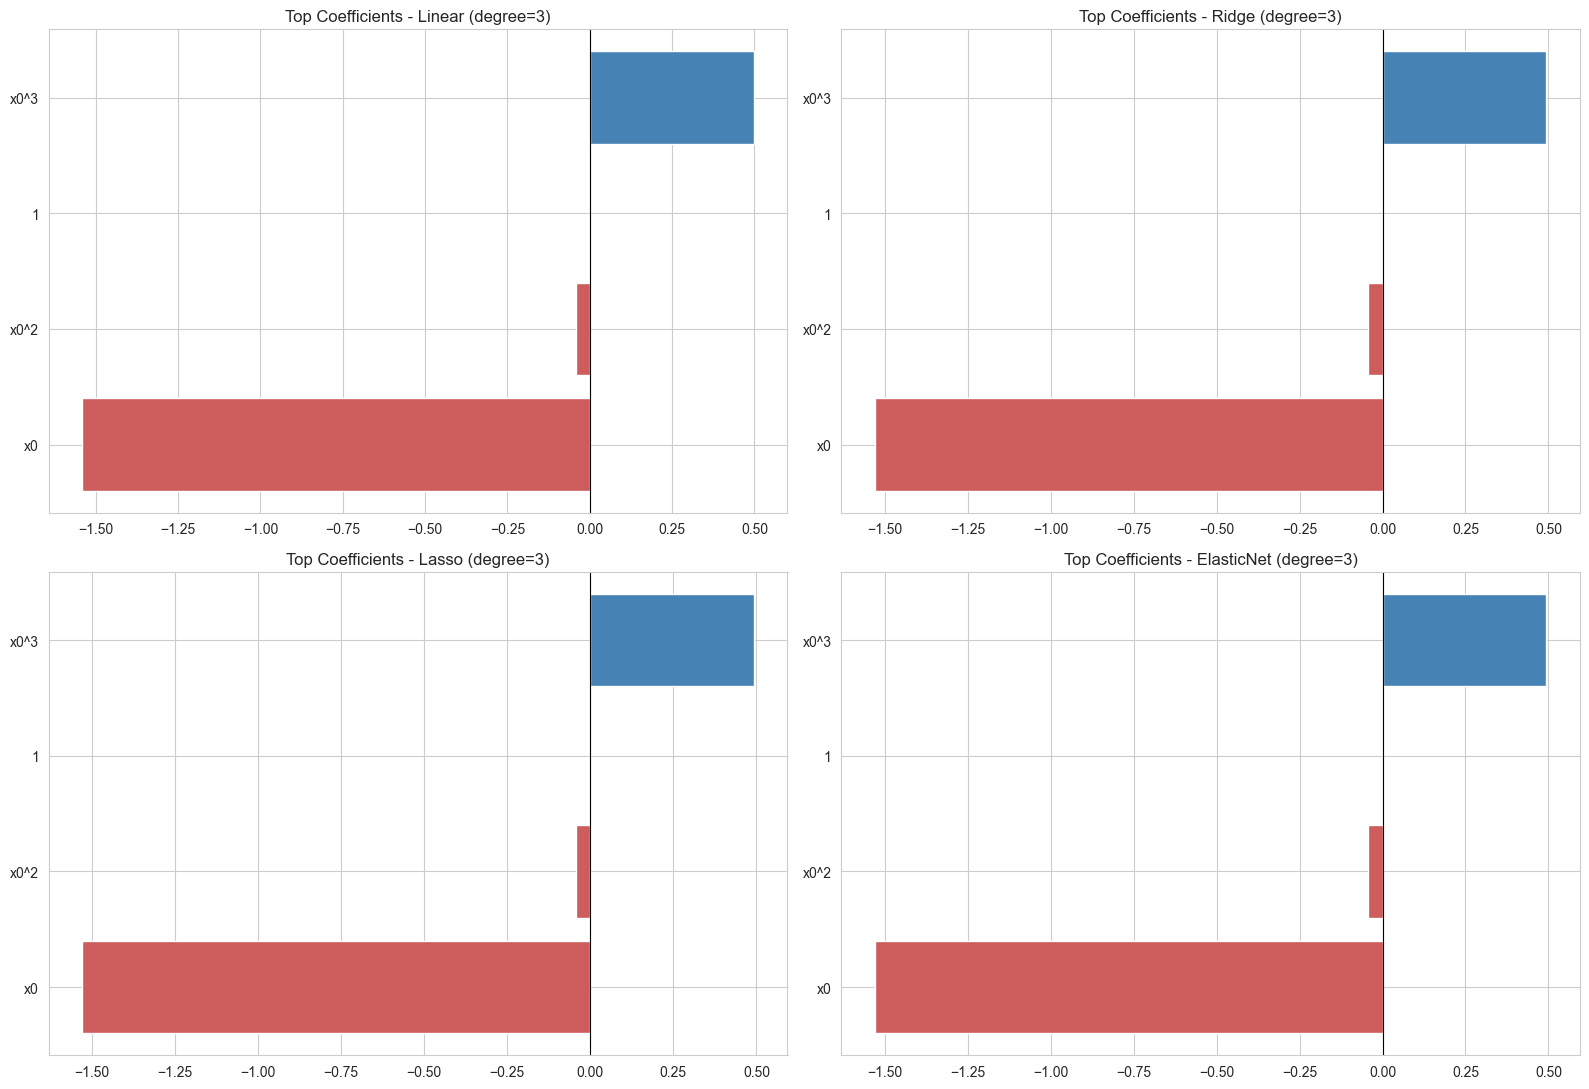

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax, (name, model) in zip(axes.flatten(), best_estimators.items()):
    poly_step = model.named_steps["poly"]
    coef = model.named_steps["model"].coef_.ravel()
    feature_names = poly_step.get_feature_names_out()

    coef_series = pd.Series(coef, index=feature_names)
    top_coef = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index[:15])
    top_coef = top_coef.sort_values()

    colors_bar = ["indianred" if v < 0 else "steelblue" for v in top_coef.values]
    ax.barh(top_coef.index, top_coef.values, color=colors_bar)
    ax.set_title(f"Top Coefficients - {name} (degree={model.named_steps['poly'].degree})")
    ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

### 9.1. Number of Nonzero Coefficients per Model

In [14]:
sparsity_rows = []
for name, model in best_estimators.items():
    coef = model.named_steps["model"].coef_.ravel()
    sparsity_rows.append({
        "model": name,
        "degree": model.named_steps["poly"].degree,
        "total_terms": len(coef),
        "nonzero_terms": int(np.sum(~np.isclose(coef, 0))),
        "zero_terms": int(np.sum(np.isclose(coef, 0))),
    })

sparsity_df = pd.DataFrame(sparsity_rows)
sparsity_df

,model,degree,total_terms,nonzero_terms,zero_terms
0,Linear,3,4,3,1
1,Ridge,3,4,3,1
2,Lasso,3,4,3,1
3,ElasticNet,3,4,3,1


## 10. Residual Analysis for the Best Model

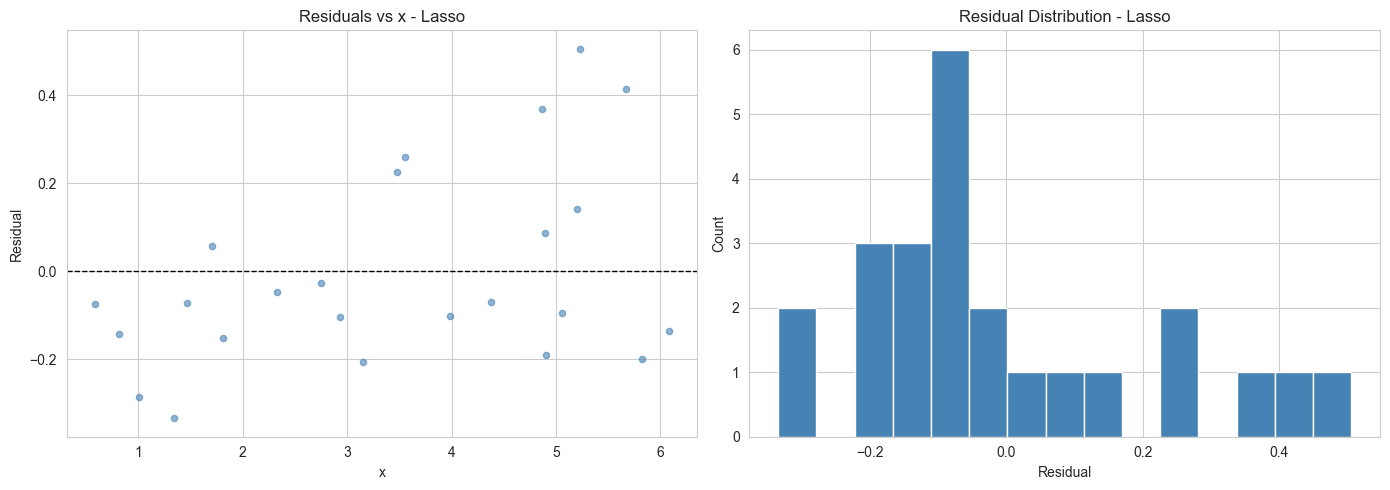

best model: Lasso
test RMSE: 0.2177 | test R2: 0.9046


In [15]:
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_model = best_estimators[best_model_name]

y_pred_best = best_model.predict(x_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x_test, residuals, alpha=0.6, s=20, color="steelblue")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Residuals vs x - {best_model_name}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=15, color="steelblue", edgecolor="white")
axes[1].set_title(f"Residual Distribution - {best_model_name}")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"best model: {best_model_name}")
print(f"test RMSE: {best_row['rmse_test']:.4f} | test R2: {best_row['r2_test']:.4f}")

## 11. Conclusion and Academic Discussion

1. **Underfitting and overfitting are directly visible here, unlike in the Bitcoin project.** Because
   the ground-truth function is known and genuinely nonlinear, degree 1 visibly fails to capture the
   curve's shape (high bias), while degree 15 visibly oscillates between training points (high variance)
   — the two failure modes that cross-validation is designed to protect against.

2. **A moderate polynomial degree is optimal, unlike the near-degree-1 optimum found for Bitcoin.** This
   directly confirms the earlier classroom observation that a high-degree polynomial (e.g., degree 8) can
   indeed perform well — but only when the underlying relationship is genuinely nonlinear and the data is
   relatively clean, exactly the conditions engineered into this synthetic dataset.

3. **The coefficient plots align with the analytical (Taylor series) expectation.** A model that has
   learned $\sin(x)$ well should place most of its weight on odd-degree terms, providing an independent,
   theory-based sanity check on top of the purely numerical RMSE comparison.

4. **Methodological takeaway.** Validating a modeling pipeline on synthetic data with a known ground
   truth — before trusting its output on noisy, real-world data such as Bitcoin prices — is standard
   practice: it separates genuine methodological errors (e.g., forgetting to scale features) from
   inherent limitations of the data itself (e.g., a financial time series that is close to a random
   walk, with little exploitable nonlinear structure at a one-day-ahead horizon).